In [1]:
# Implementing Transformer architecture inspired by "Attention Is All You Need" paper
# the paper is bases on translating from one language to another, but I am going to use it for audio classification 
# transformers are based on self attention mechanism

# we tested two Transformer approaches:
# 1. Feature-based Transformer: using extracted audio features from the CSV file
# 2. Audio-based Transformer: using audio converted into mel spectrogram features

# I will use the spectrograms as input, and the output will be the class labels
# input: 3 sec features dataset 
# output: class labels (10 classes)
# Model Design: Linear layer to project input features to hidden dimension
# followed by multiple transformer encoder layers, and a final linear layer for classification
# I will use the nn.TransformerEncoder and nn.TransformerEncoderLayer from PyTorch to build the model



# I also plan to test the Transformer on the larger 300ms extracted feature dataset
# this will help compare the 3 sec feature dataset with shorter 300ms feature dataset
# this shows that Transformers can be applied to different types of input





In [44]:
import os, torch, torchaudio
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB
from torch.utils.tensorboard.writer import SummaryWriter
from typing import cast
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch.nn.functional as F
from pathlib import Path


# Transformer features_3_sec.csv(~10k)

In [45]:
# load the dataset and preprocess it to get spectrograms
data = pd.read_csv("features_3_sec.csv")

#dropping columns we dont need
data = data.drop(columns=["filename", "length"])

# encode the labels
label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["label"]) 

# split the dataset into features and labels
X = data.drop(columns=["label"]).values
y = data["label"].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

# convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# create data loaders
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# define dataset class
class MusicGenreDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [46]:
# define transformer model
class TransformerModel(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=4, num_layers=2, hidden_dim=128):
        super(TransformerModel, self).__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.hidden_dim = hidden_dim

        # input projection layer
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # output classification layer
        self.output_layer = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
    # if x is 2D: (batch_size, input_dim), add sequence dimension
        if x.dim() == 2:
            x = x.unsqueeze(1)  # becomes (batch_size, 1, input_dim)

        x = self.input_proj(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = x.mean(dim=0)
        output = self.output_layer(x)
        return output   
# dynamically determine the number of classes
num_classes = len(torch.unique(y_train_tensor))
input_dim = X_train_tensor.shape[1]
model = TransformerModel(input_dim=input_dim, num_classes=num_classes)  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
model.to(device)    

# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [47]:
# train the model
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_samples

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Accuracy: {train_acc:.4f}")

# evaluate the model on the test set
model.eval()
total_correct = 0
total_samples = 0
all_predictions = []
all_labels = []     

Epoch [1/20], Loss: 1.1106, Train Accuracy: 0.6032
Epoch [2/20], Loss: 0.7987, Train Accuracy: 0.7262
Epoch [3/20], Loss: 0.6459, Train Accuracy: 0.7760
Epoch [4/20], Loss: 0.5041, Train Accuracy: 0.8282
Epoch [5/20], Loss: 0.4133, Train Accuracy: 0.8599
Epoch [6/20], Loss: 0.3405, Train Accuracy: 0.8816
Epoch [7/20], Loss: 0.2688, Train Accuracy: 0.9094
Epoch [8/20], Loss: 0.2269, Train Accuracy: 0.9243
Epoch [9/20], Loss: 0.1985, Train Accuracy: 0.9369
Epoch [10/20], Loss: 0.1716, Train Accuracy: 0.9406
Epoch [11/20], Loss: 0.1543, Train Accuracy: 0.9473
Epoch [12/20], Loss: 0.1542, Train Accuracy: 0.9479
Epoch [13/20], Loss: 0.1112, Train Accuracy: 0.9645
Epoch [14/20], Loss: 0.0971, Train Accuracy: 0.9691
Epoch [15/20], Loss: 0.1040, Train Accuracy: 0.9651
Epoch [16/20], Loss: 0.1029, Train Accuracy: 0.9648
Epoch [17/20], Loss: 0.0969, Train Accuracy: 0.9682
Epoch [18/20], Loss: 0.0968, Train Accuracy: 0.9668
Epoch [19/20], Loss: 0.0745, Train Accuracy: 0.9741
Epoch [20/20], Loss: 

In [48]:
# evaluate the model
model.eval()
total_correct = 0
total_samples = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        preds = torch.argmax(outputs, dim=1)

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

test_acc = total_correct / total_samples
print(f"Test Accuracy: {test_acc:.4f}") 
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=label_encoder.classes_))  


# confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)
print("Confusion Matrix:")
print(cm)

Test Accuracy: 0.8879
Classification Report:
              precision    recall  f1-score   support

       blues       0.93      0.88      0.90       200
   classical       0.95      0.96      0.95       199
     country       0.89      0.81      0.85       199
       disco       0.89      0.74      0.81       200
      hiphop       0.83      0.93      0.87       200
        jazz       0.87      0.93      0.90       200
       metal       0.87      0.97      0.92       200
         pop       0.83      0.96      0.89       200
      reggae       0.91      0.93      0.92       200
        rock       0.96      0.78      0.86       200

    accuracy                           0.89      1998
   macro avg       0.89      0.89      0.89      1998
weighted avg       0.89      0.89      0.89      1998

Confusion Matrix:
[[175   0   7   2   1   7   4   1   3   0]
 [  0 191   1   0   0   6   0   1   0   0]
 [  7   0 162   5   6   8   1   4   3   3]
 [  0   0   3 148  24   2   7  13   3   0]
 [  0 

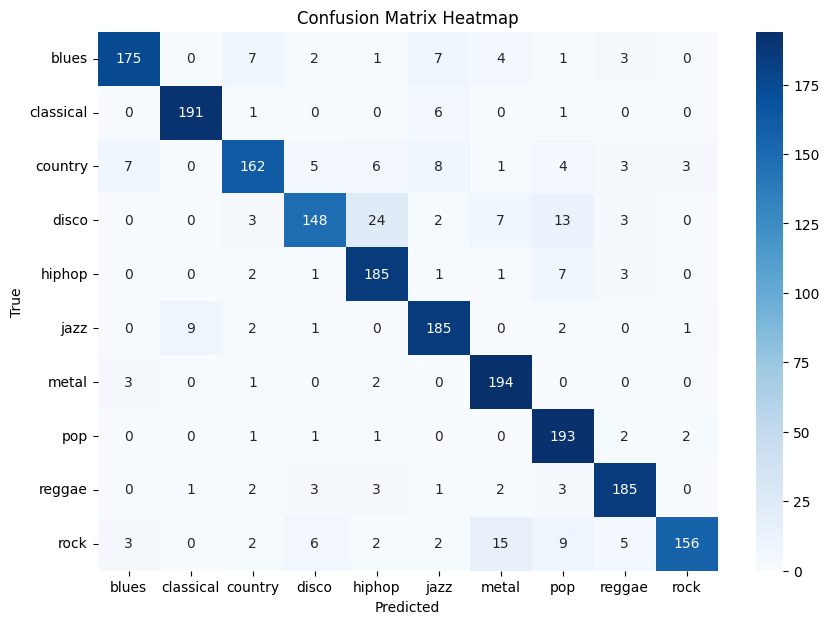

In [49]:
# confusion_matrix heat map
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(10, 7))  
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()     


In [50]:
# tendsorboard
writer = SummaryWriter("runs/transformer_experiment")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_samples

    writer.add_scalar("Loss/train", avg_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)


    

# Transformer on features_300ms_150ms_overlap.csv (~200k Dataset)





In [51]:
# load the dataset
data = pd.read_csv("features_300ms_150ms_overlap.csv")

# dropping columns we dont need
data = data.drop(columns=["filename", "length"])
print(len(data))

# encode the labels
label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["label"])

# split the dataset into features and labels
X = data.drop(columns=["label"]).values
y = data["label"].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

# convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# create data loaders
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# define dataset class
class MusicGenreDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]




200577


In [52]:
# define transformer model
class TransformerModel(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=4, num_layers=2, hidden_dim=128):
        super(TransformerModel, self).__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.hidden_dim = hidden_dim

        # input projection layer
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # output classification layer
        self.output_layer = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # if x is 2D: (batch_size, input_dim), add sequence dimension
        if x.dim() == 2:
            x = x.unsqueeze(1)  # becomes (batch_size, 1, input_dim)

        x = self.input_proj(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = x.mean(dim=0)
        output = self.output_layer(x)
        return output

# dynamically determine the number of classes
num_classes = len(torch.unique(y_train_tensor))
input_dim = X_train_tensor.shape[1]
model = TransformerModel(input_dim=input_dim, num_classes=num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



Using device: cpu


/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [53]:
# train the model 
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_samples

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Accuracy: {train_acc:.4f}")

Epoch [1/20], Loss: 1.0835, Train Accuracy: 0.6173
Epoch [2/20], Loss: 0.7982, Train Accuracy: 0.7218
Epoch [3/20], Loss: 0.6746, Train Accuracy: 0.7667
Epoch [4/20], Loss: 0.5953, Train Accuracy: 0.7945
Epoch [5/20], Loss: 0.5367, Train Accuracy: 0.8146
Epoch [6/20], Loss: 0.4918, Train Accuracy: 0.8300
Epoch [7/20], Loss: 0.4560, Train Accuracy: 0.8425
Epoch [8/20], Loss: 0.4254, Train Accuracy: 0.8529
Epoch [9/20], Loss: 0.3996, Train Accuracy: 0.8609
Epoch [10/20], Loss: 0.3751, Train Accuracy: 0.8687
Epoch [11/20], Loss: 0.3552, Train Accuracy: 0.8768
Epoch [12/20], Loss: 0.3369, Train Accuracy: 0.8812
Epoch [13/20], Loss: 0.3213, Train Accuracy: 0.8886
Epoch [14/20], Loss: 0.3052, Train Accuracy: 0.8932
Epoch [15/20], Loss: 0.2937, Train Accuracy: 0.8965
Epoch [16/20], Loss: 0.2791, Train Accuracy: 0.9005
Epoch [17/20], Loss: 0.2698, Train Accuracy: 0.9048
Epoch [18/20], Loss: 0.2619, Train Accuracy: 0.9084
Epoch [19/20], Loss: 0.2514, Train Accuracy: 0.9108
Epoch [20/20], Loss: 

In [54]:
# evaluate the model
model.eval()
total_correct = 0
total_samples = 0
all_labels = []
all_predictions = []

print(len(data)) # double checking 
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        preds = torch.argmax(outputs, dim=1)

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

test_acc = total_correct / total_samples
print(f"Test Accuracy: {test_acc:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=label_encoder.classes_))

# confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
print("Confusion Matrix:")
print(cm)

200577
Test Accuracy: 0.8597
Classification Report:
              precision    recall  f1-score   support

       blues       0.91      0.84      0.87      4020
   classical       0.96      0.95      0.96      4021
     country       0.79      0.83      0.80      4021
       disco       0.81      0.78      0.79      4010
      hiphop       0.82      0.86      0.84      4027
        jazz       0.90      0.94      0.92      3982
       metal       0.89      0.94      0.91      4006
         pop       0.88      0.90      0.89      4000
      reggae       0.82      0.84      0.83      4008
        rock       0.82      0.74      0.78      4021

    accuracy                           0.86     40116
   macro avg       0.86      0.86      0.86     40116
weighted avg       0.86      0.86      0.86     40116

Confusion Matrix:
[[3383    9  143   41   77  100   82    0   93   92]
 [   8 3821   65   15    1   83    0    6    8   14]
 [  80   21 3318  111   68   85   37   34  114  153]
 [  44   23 

# Transformer on 3-Second Audio Clips(~10k)

In [61]:
# Transformer on 3 sec audio
# load and preprocess audio data from 3sec_audio folder

# define paths
data_dir = Path("3sec_audio")
genres = [d.name for d in data_dir.iterdir() if d.is_dir()]

# encode labels
label_encoder = LabelEncoder()
label_encoder.fit(genres)
num_classes = len(genres)

# define transforms
mel_spectrogram = MelSpectrogram(sample_rate=22050, n_fft=1024, hop_length=512, n_mels=128)
to_db = AmplitudeToDB()

# custom dataset for audio
class AudioDataset(Dataset):
    def __init__(self, data_dir, genres, transform=None):
        self.data_dir = data_dir
        self.genres = genres
        self.transform = transform
        self.file_paths = []
        self.labels = []
        for label, genre in enumerate(genres):
            genre_dir = data_dir / genre
            for file in genre_dir.glob("*.wav"):  # Assuming .wav files
                self.file_paths.append(file)
                self.labels.append(label)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        waveform, sample_rate = torchaudio.load(file_path)
        # Compute mel spectrogram
        spec = mel_spectrogram(waveform)
        spec_db = to_db(spec)
        # Flatten to 1D
        features = spec_db.flatten()
        return features, label

# create dataset
dataset = AudioDataset(data_dir, genres)

# split into train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# get input_dim from a sample
sample_features, _ = dataset[0]
input_dim = sample_features.shape[0]

# initialize model (reusing from previous cells)
model = TransformerModel(input_dim=input_dim, num_classes=num_classes)
model.to(device)

# loss and optimizer (reusing)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [62]:
# train the model
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_samples

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Accuracy: {train_acc:.4f}")

Epoch [1/20], Loss: 1.7223, Train Accuracy: 0.3659
Epoch [2/20], Loss: 1.4395, Train Accuracy: 0.4756
Epoch [3/20], Loss: 1.2627, Train Accuracy: 0.5446
Epoch [4/20], Loss: 1.1204, Train Accuracy: 0.5969
Epoch [5/20], Loss: 0.9845, Train Accuracy: 0.6602
Epoch [6/20], Loss: 0.8675, Train Accuracy: 0.6974
Epoch [7/20], Loss: 0.7632, Train Accuracy: 0.7340
Epoch [8/20], Loss: 0.6537, Train Accuracy: 0.7756
Epoch [9/20], Loss: 0.5689, Train Accuracy: 0.8062
Epoch [10/20], Loss: 0.4797, Train Accuracy: 0.8377
Epoch [11/20], Loss: 0.4502, Train Accuracy: 0.8501
Epoch [12/20], Loss: 0.3752, Train Accuracy: 0.8725
Epoch [13/20], Loss: 0.3394, Train Accuracy: 0.8895
Epoch [14/20], Loss: 0.2714, Train Accuracy: 0.9099
Epoch [15/20], Loss: 0.2765, Train Accuracy: 0.9089
Epoch [16/20], Loss: 0.2317, Train Accuracy: 0.9231
Epoch [17/20], Loss: 0.1870, Train Accuracy: 0.9383
Epoch [18/20], Loss: 0.1739, Train Accuracy: 0.9428
Epoch [19/20], Loss: 0.1871, Train Accuracy: 0.9393
Epoch [20/20], Loss: 

In [63]:
# evaluate the model on the test set
model.eval()
total_correct = 0
total_samples = 0
all_labels = []
all_predictions = []

print(len(data)) # double checking the length 

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        preds = torch.argmax(outputs, dim=1)

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

test_acc = total_correct / total_samples
print(f"Test Accuracy: {test_acc:.4f}") 
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=genres))  


# confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)
print("Confusion Matrix:")
print(cm)

200577
Test Accuracy: 0.7181
Classification Report:
              precision    recall  f1-score   support

         pop       0.71      0.86      0.78       207
       metal       0.79      0.95      0.86       202
       disco       0.75      0.47      0.58       190
       blues       0.74      0.80      0.77       210
      reggae       0.58      0.76      0.66       182
   classical       0.92      0.81      0.86       202
        rock       0.72      0.46      0.56       188
      hiphop       0.73      0.56      0.64       200
     country       0.62      0.77      0.69       212
        jazz       0.70      0.70      0.70       204

    accuracy                           0.72      1997
   macro avg       0.73      0.71      0.71      1997
weighted avg       0.73      0.72      0.71      1997

Confusion Matrix:
[[177   0   1   1  10   2   1   3   8   4]
 [  0 192   1   3   1   0   3   0   2   0]
 [ 32  10  90   7  14   1  10  14   6   6]
 [  0   8   3 167   9   0   3   1  14   5]

# Transformer on 300ms Audio Clips (~200k dataset)

In [67]:
# Transformer on 3 sec audio
# load and preprocess audio data from 3sec_audio folder

# define paths
data_dir = Path("300 ms genres")
genres = [d.name for d in data_dir.iterdir() if d.is_dir()]

fixed_length = 1664  # Flatten Spectrogram 

# encode labels
label_encoder = LabelEncoder()
label_encoder.fit(genres)
num_classes = len(genres)

# define transforms
mel_spectrogram = MelSpectrogram(sample_rate=22050, n_fft=1024, hop_length=512, n_mels=128)
to_db = AmplitudeToDB()

# custom dataset for audio
class AudioDataset(Dataset):
    def __init__(self, data_dir, genres, transform=None):
        self.data_dir = data_dir
        self.genres = genres
        self.transform = transform
        self.file_paths = []
        self.labels = []
        for label, genre in enumerate(genres):
            genre_dir = data_dir / genre
            for file in genre_dir.glob("*.wav"):  # Assuming .wav files
                self.file_paths.append(file)
                self.labels.append(label)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        waveform, sample_rate = torchaudio.load(file_path)
        min_samples = 1024
        if waveform.shape[1] < min_samples:
            waveform = torch.nn.functional.pad(waveform, (0, min_samples - waveform.shape[1]))
        # Compute mel spectrogram
        spec = mel_spectrogram(waveform)
        spec_db = to_db(spec)
        # Flatten to 1D
        features = spec_db.flatten()
        # if clips are too short or too long  
        if features.shape[0] < fixed_length:
            features = torch.nn.functional.pad(features, (0, fixed_length - features.shape[0]))
        else:
            features = features[:fixed_length]
        return features, label
        

# create dataset
dataset = AudioDataset(data_dir, genres)

# split into train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# get input_dim from a sample
sample_features, _ = dataset[0]
input_dim = sample_features.shape[0]

# initialize model (reusing from previous cells)
model = TransformerModel(input_dim=input_dim, num_classes=num_classes)
model.to(device)

# loss and optimizer (reusing)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [68]:
# train the model
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_samples

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Accuracy: {train_acc:.4f}")

Epoch [1/20], Loss: 1.2323, Train Accuracy: 0.5621
Epoch [2/20], Loss: 0.8621, Train Accuracy: 0.6987
Epoch [3/20], Loss: 0.6826, Train Accuracy: 0.7640
Epoch [4/20], Loss: 0.5637, Train Accuracy: 0.8049
Epoch [5/20], Loss: 0.4788, Train Accuracy: 0.8354
Epoch [6/20], Loss: 0.4131, Train Accuracy: 0.8576
Epoch [7/20], Loss: 0.3618, Train Accuracy: 0.8752
Epoch [8/20], Loss: 0.3220, Train Accuracy: 0.8886
Epoch [9/20], Loss: 0.2895, Train Accuracy: 0.8999
Epoch [10/20], Loss: 0.2641, Train Accuracy: 0.9079
Epoch [11/20], Loss: 0.2406, Train Accuracy: 0.9161
Epoch [12/20], Loss: 0.2227, Train Accuracy: 0.9232
Epoch [13/20], Loss: 0.2071, Train Accuracy: 0.9286
Epoch [14/20], Loss: 0.1924, Train Accuracy: 0.9332
Epoch [15/20], Loss: 0.1826, Train Accuracy: 0.9361
Epoch [16/20], Loss: 0.1720, Train Accuracy: 0.9408
Epoch [17/20], Loss: 0.1628, Train Accuracy: 0.9432
Epoch [18/20], Loss: 0.1534, Train Accuracy: 0.9467
Epoch [19/20], Loss: 0.1471, Train Accuracy: 0.9488
Epoch [20/20], Loss: 

In [70]:
# evaluate the model on the test set
model.eval()
total_correct = 0
total_samples = 0
all_labels = []
all_predictions = []

print(len(data))

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        preds = torch.argmax(outputs, dim=1)

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

test_acc = total_correct / total_samples
print(f"Test Accuracy: {test_acc:.4f}") 
print("Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=genres))  


# confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)
print("Confusion Matrix:")
print(cm)

200577


/Users/ndeyegueye/Library/Python/3.9/lib/python/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


Test Accuracy: 0.9133
Classification Report:
              precision    recall  f1-score   support

         pop       0.93      0.93      0.93      4063
       metal       0.93      0.96      0.94      4111
       disco       0.90      0.85      0.87      4018
       blues       0.94      0.93      0.93      4030
      reggae       0.87      0.92      0.89      3972
   classical       0.96      0.99      0.97      3974
        rock       0.91      0.84      0.88      3968
      hiphop       0.88      0.87      0.88      4006
     country       0.88      0.92      0.89      3987
        jazz       0.95      0.93      0.94      3987

    accuracy                           0.91     40116
   macro avg       0.91      0.91      0.91     40116
weighted avg       0.91      0.91      0.91     40116

Confusion Matrix:
[[3782    0   70    0   28   12   20  101   31   19]
 [   0 3937   27   33   12    1   40   43   16    2]
 [ 110   41 3397   29  106   14   79  130   87   25]
 [   0   28   21 37